### day2

#### 데이터 읽어온 후 datetime 형태 변환

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
submission_df = pd.read_csv('data/sampleSubmission.csv')

In [3]:
# datetime 변수 분해
train_df['datetime']=pd.to_datetime(train_df['datetime'])
train_df['year']=train_df['datetime'].dt.year
train_df['month']=train_df['datetime'].dt.month
train_df['day']=train_df['datetime'].dt.day
train_df['hour']=train_df['datetime'].dt.hour
train_df['minute']=train_df['datetime'].dt.minute
train_df['second']=train_df['datetime'].dt.second
train_df=train_df.drop(columns=['minute','second'], axis=1)
test_df['datetime'] = pd.to_datetime(test_df['datetime'])
test_df['year'] = test_df['datetime'].dt.year
test_df['month'] = test_df['datetime'].dt.month
test_df['day'] = test_df['datetime'].dt.day
test_df['hour'] = test_df['datetime'].dt.hour

#### 모델 학습 및 답안 제출

In [4]:
X = train_df.drop(columns=['count','casual','registered','datetime'])
y = train_df['count']

In [5]:
X_test = test_df.drop(columns=['datetime'])

In [6]:
print(f'Train data shape : {X.shape}')
print(f'Number of null values : {X.isna().sum().sum()}')
print(f'Test data shape : {X_test.shape}')
print(f'Number of null values : {X_test.isna().sum().sum()}')

Train data shape : (10886, 12)
Number of null values : 0
Test data shape : (6493, 12)
Number of null values : 0


In [7]:
X.columns, X_test.columns

(Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
        'humidity', 'windspeed', 'year', 'month', 'day', 'hour'],
       dtype='object'),
 Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
        'humidity', 'windspeed', 'year', 'month', 'day', 'hour'],
       dtype='object'))

In [8]:
def separate_train(df):
    X = df.drop(columns=['count','casual','registered','datetime'], axis=1)
    y = df['count']
    return X, y

def separate_test(df):
    X_test = df.drop('datetime', axis=1)
    return X_test

In [9]:
X, y = separate_train(train_df)
X_test = separate_test(test_df)

print(f'Train data shape : {X.shape}')
print(f'Number of null values : {X.isna().sum().sum()}')
print(f'Test data shape : {X_test.shape}')
print(f'Number of null values : {X_test.isna().sum().sum()}')

Train data shape : (10886, 12)
Number of null values : 0
Test data shape : (6493, 12)
Number of null values : 0


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_valid_pred = model.predict(X_valid)

In [13]:
y_valid_pred = np.maximum(0, y_valid_pred)

In [14]:
from sklearn.metrics import mean_squared_log_error 

rmsle = np.sqrt(mean_squared_log_error(y_valid, y_valid_pred))
print(f'\nValidation RMSLE: {rmsle:.5f}')


Validation RMSLE: 1.30575


In [15]:
y_test_pred = model.predict(X_test)
y_test_pred = np.maximum(0, y_test_pred)

In [18]:
submission_df['count'] = y_test_pred
submission_df.to_csv('result/submission_baseline.csv', index=False)
submission_df

,datetime,count
0,2011-01-20 00:00:00,0.000000
1,2011-01-20 01:00:00,0.000000
2,2011-01-20 02:00:00,0.000000
3,2011-01-20 03:00:00,0.000000
4,2011-01-20 04:00:00,0.000000
...,...,...
6488,2012-12-31 19:00:00,299.166115
6489,2012-12-31 20:00:00,307.029709
6490,2012-12-31 21:00:00,320.079545
6491,2012-12-31 22:00:00,338.774422


Private Score / Public Score : 1.34066 / 1.34066

#### 피처 엔지니어링 (Feature Engineering)_1

- 디테일한 EDA

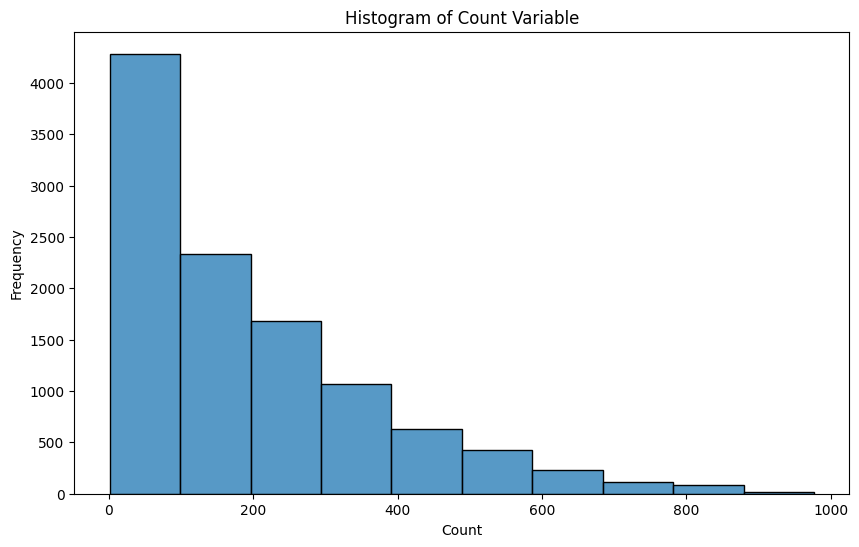

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='count', bins=10)
plt.title('Histogram of Count Variable')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()

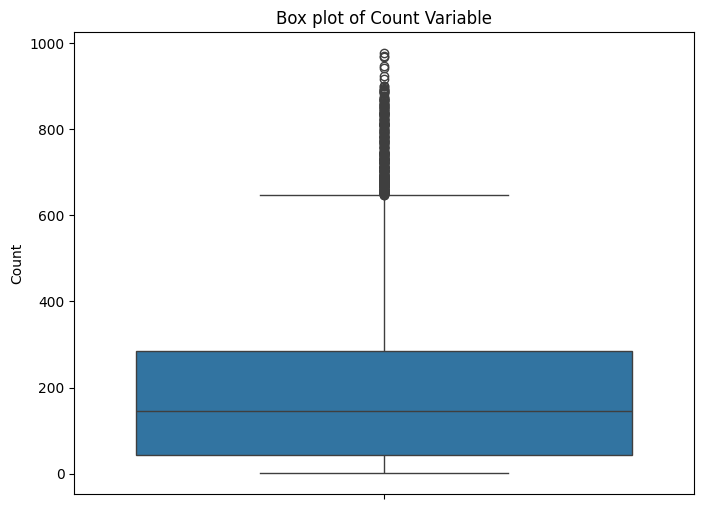

In [21]:
plt.figure(figsize=(8,6))
sns.boxplot(data=train_df, y='count')
plt.title('Box plot of Count Variable')
plt.ylabel('Count')
plt.show()

In [22]:
train_df['count'].min()

np.int64(1)

count의 최솟값이 1로 추정된다. 데이터를 자세히 살펴보면 자전거 대여가 없는 시간대에는 count값이 0으로 되어 있는것이 아니라 아예 그 시간대에 해당하는 행이 존재하지 않는다.

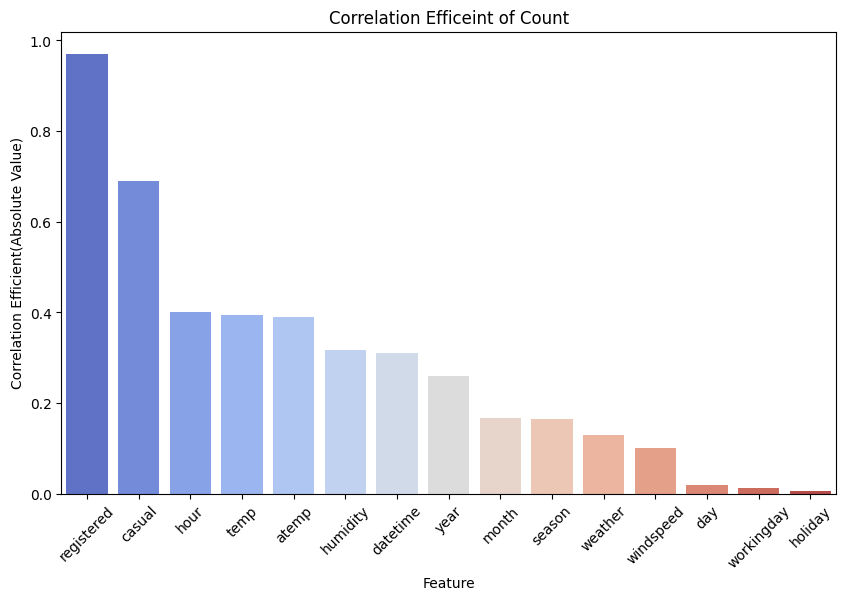

In [23]:
df = pd.DataFrame(train_df)

correlation_matrix = df.corr()

corr_df=correlation_matrix['count'].abs().sort_values(ascending=False).drop('count')

plt.figure(figsize=(10,6))
sns.barplot(data=corr_df.reset_index(), x='index', y='count', hue='index', palette='coolwarm', legend=False)
plt.xlabel('Feature')
plt.ylabel('Correlation Efficient(Absolute Value)')
plt.title('Correlation Efficeint of Count')
plt.xticks(rotation=45)
plt.show()

In [24]:
for col in ['year', 'month', 'day', 'hour']:
    unique_values = train_df[col].unique()
    unique_values.sort()
    print(col)
    print(unique_values)

year
[2011 2012]
month
[ 1  2  3  4  5  6  7  8  9 10 11 12]
day
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
hour
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [25]:
for col in ['year', 'month', 'day', 'hour'] :
    unique_values = sorted(test_df[col].unique())
    print(col)
    print(unique_values)


year
[np.int32(2011), np.int32(2012)]
month
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
day
[np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]
hour
[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]


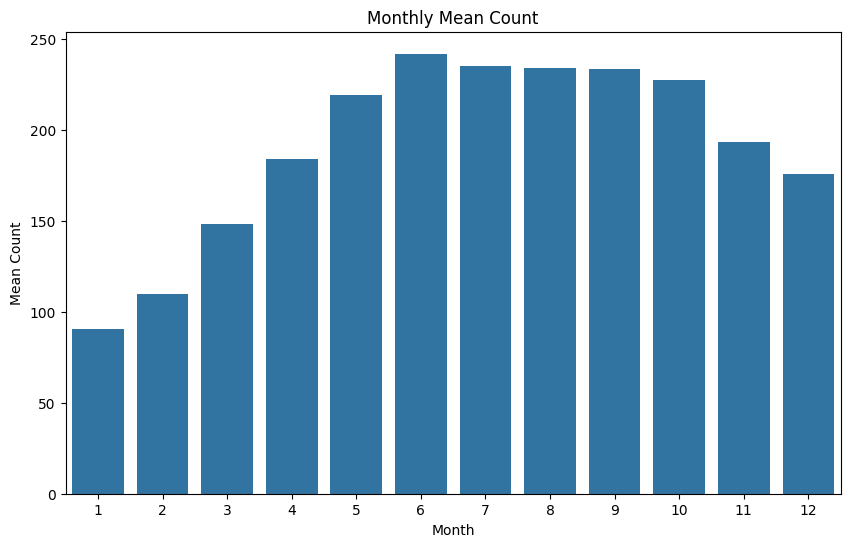

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(data=train_df, x='month', y='count', errorbar=None)
plt.title('Monthly Mean Count')
plt.xlabel('Month')
plt.ylabel('Mean Count')
plt.show()

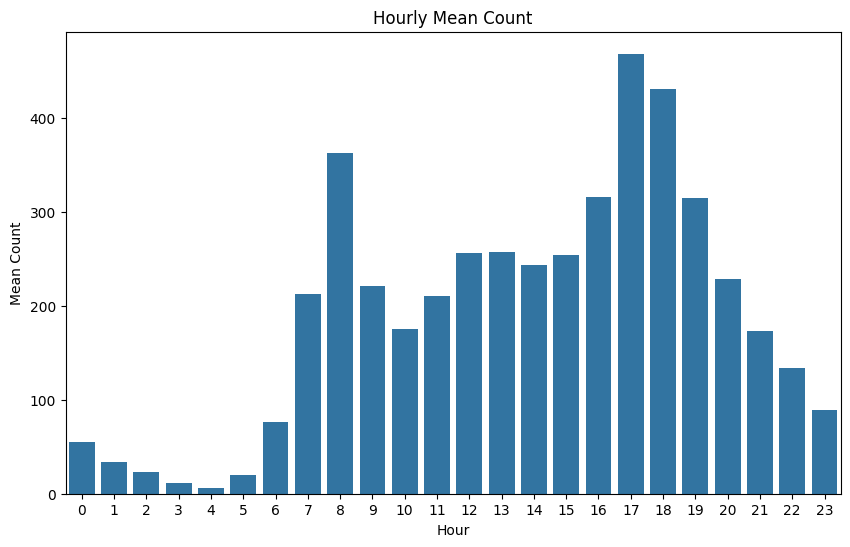

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(data=train_df, x='hour', y='count', errorbar=None)
plt.title('Hourly Mean Count')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.show()

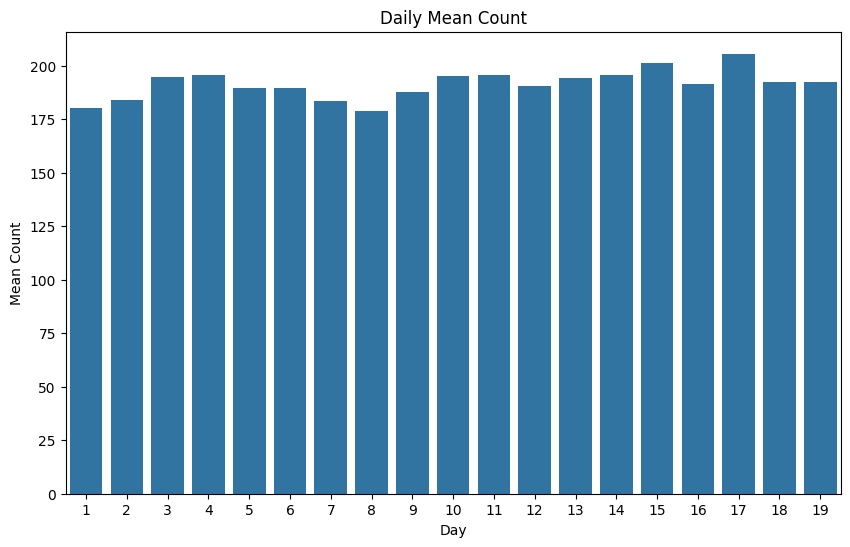

In [28]:
plt.figure(figsize=(10,6))
sns.barplot(data=train_df, x='day', y='count', errorbar=None)
plt.title('Daily Mean Count')
plt.xlabel('Day')
plt.ylabel('Mean Count')
plt.show()

날짜와 대여량 사이에는 유의미(크나큰)한 차이가 존재하지는 않는 것으로 보인다. - 인사이트

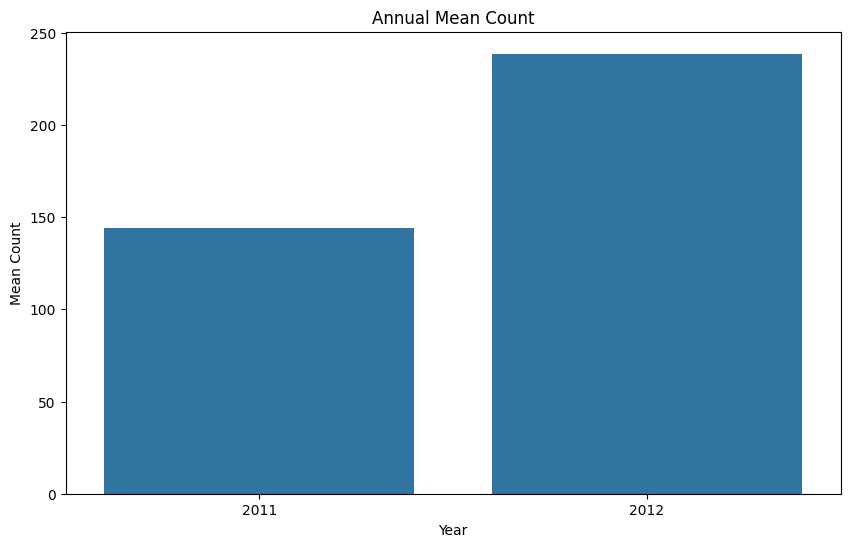

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(data=train_df, x='year', y='count', errorbar=None)
plt.title('Annual Mean Count')
plt.xlabel('Year')
plt.ylabel('Mean Count')
plt.show()

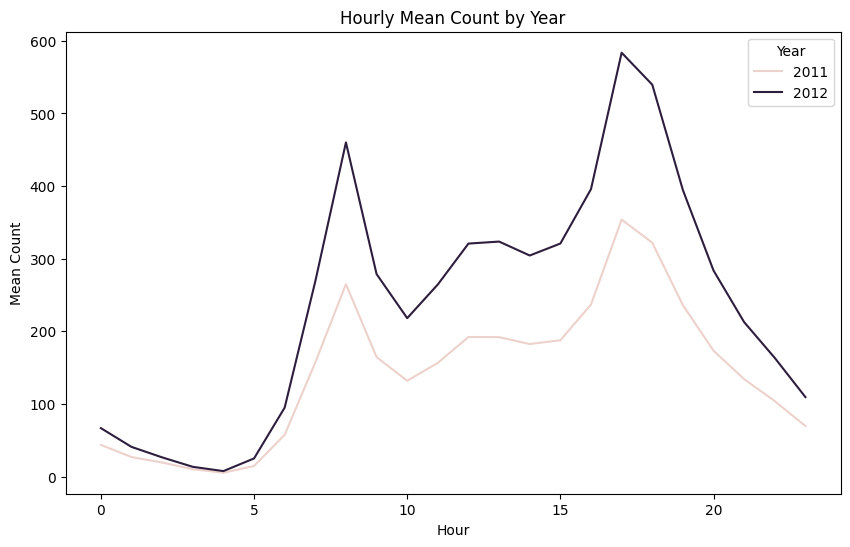

In [30]:
plt.figure(figsize=(10,6))
sns.lineplot(data=train_df, x='hour', y='count', hue='year', errorbar=None)
plt.title('Hourly Mean Count by Year')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.legend(title='Year')
plt.show()

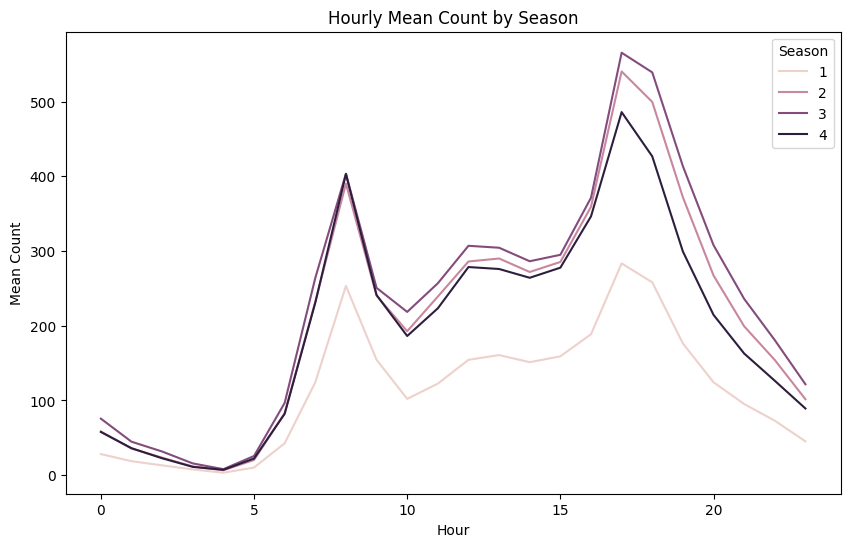

In [31]:
plt.figure(figsize=(10,6))
sns.lineplot(data=train_df, x='hour', y='count', hue='season', errorbar=None)
plt.title('Hourly Mean Count by Season')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.legend(title='Season')
plt.show()

Season 변수는 1부터 4까지 4개의 값으로 이루어져 있기 때문에 4개의 라인차트를 확인할 수 있고, 전체적인 그래프의 모양은 모두 비슷하게 생겼다. 그런데 Season이 1일 때에는 출퇴근 시간대에도 대여량의 증가폭이 작은 편이다.

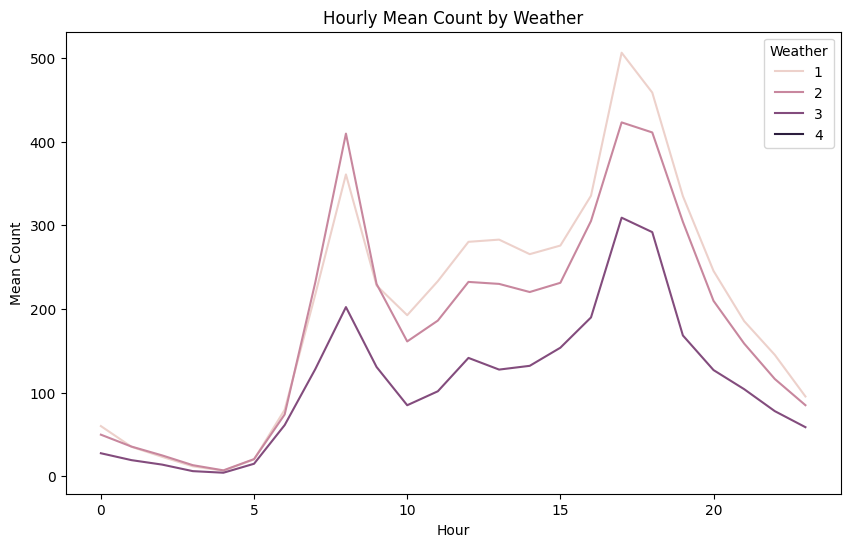

In [32]:
plt.figure(figsize=(10,6))
sns.lineplot(data=train_df, x='hour', y='count', hue='weather', errorbar=None)
plt.title('Hourly Mean Count by Weather')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.legend(title='Weather')
plt.show()

In [33]:
train_df['weather'].value_counts()

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

그래프의 범례(legend)를 보면 그래프가 4개가 보여야 하는데, 3개밖에 안 보이는 이유는 weather가 4인 데이터가 딱 하나밖에 없기 때문이다.

In [34]:
train_df['temp'].unique() 

array([ 9.84,  9.02,  8.2 , 13.12, 15.58, 14.76, 17.22, 18.86, 18.04,
       16.4 , 13.94, 12.3 , 10.66,  6.56,  5.74,  7.38,  4.92, 11.48,
        4.1 ,  3.28,  2.46, 21.32, 22.96, 23.78, 24.6 , 19.68, 22.14,
       20.5 , 27.06, 26.24, 25.42, 27.88, 28.7 , 30.34, 31.16, 29.52,
       33.62, 35.26, 36.9 , 32.8 , 31.98, 34.44, 36.08, 37.72, 38.54,
        1.64,  0.82, 39.36, 41.  ])

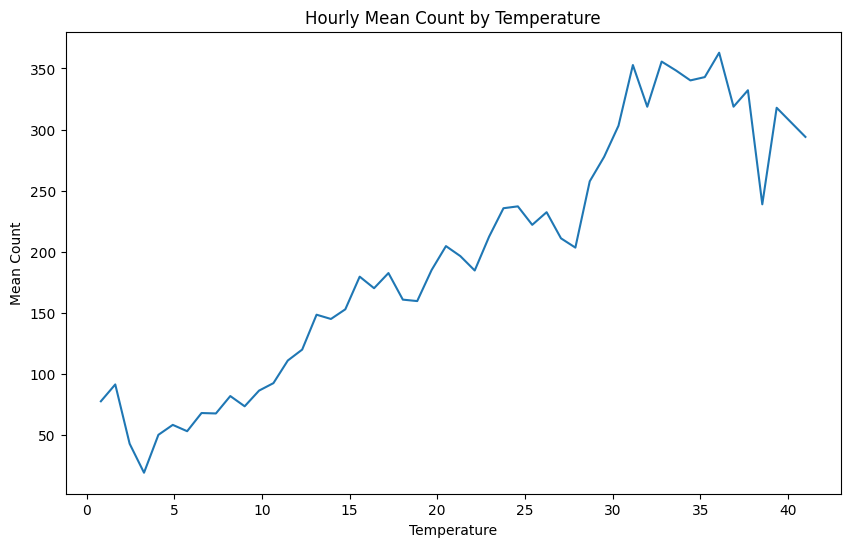

In [35]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='temp', y='count', errorbar=None)
plt.title('Hourly Mean Count by Temperature')
plt.xlabel('Temperature')
plt.ylabel('Mean Count')
plt.show()

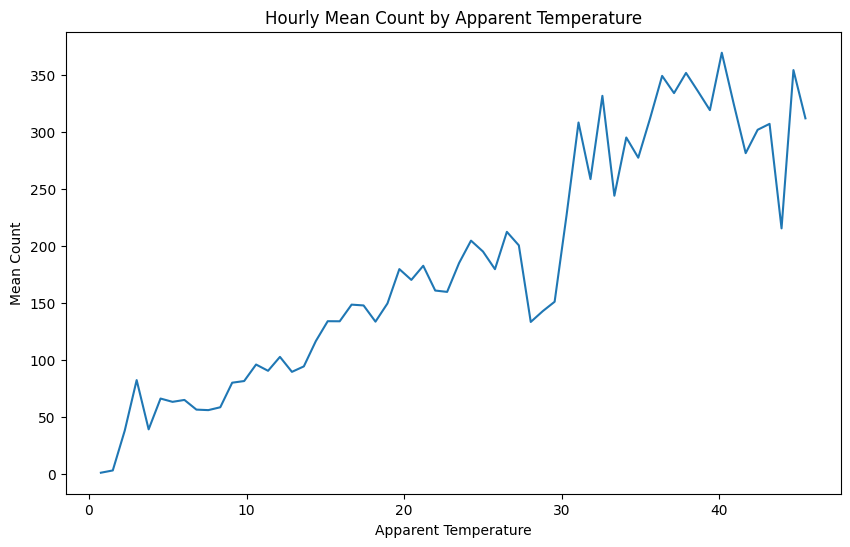

In [36]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='atemp', y='count', errorbar=None)
plt.title('Hourly Mean Count by Apparent Temperature')
plt.xlabel('Apparent Temperature')
plt.ylabel('Mean Count')
plt.show()

온도, 체감온도는 비슷한 양상을 보여주는데, 증가할수록 자전거 대여량도 같이 증가하는 경향을 보인다.

#### 피처 엔지니어링 (Feature Engineering)_2 

- 변수 추가

day_of_week 변수 추가하기

- day of week 변수 추가는 무슨 요일인지 숫자로 나타내서 월요일부터 일요일까지를 각각 0~6 사이의 숫자에 대응시켜 나타낸다.

In [37]:
train_df['day_of_week'] = train_df['datetime'].dt.dayofweek
test_df['day_of_week'] = test_df['datetime'].dt.dayofweek

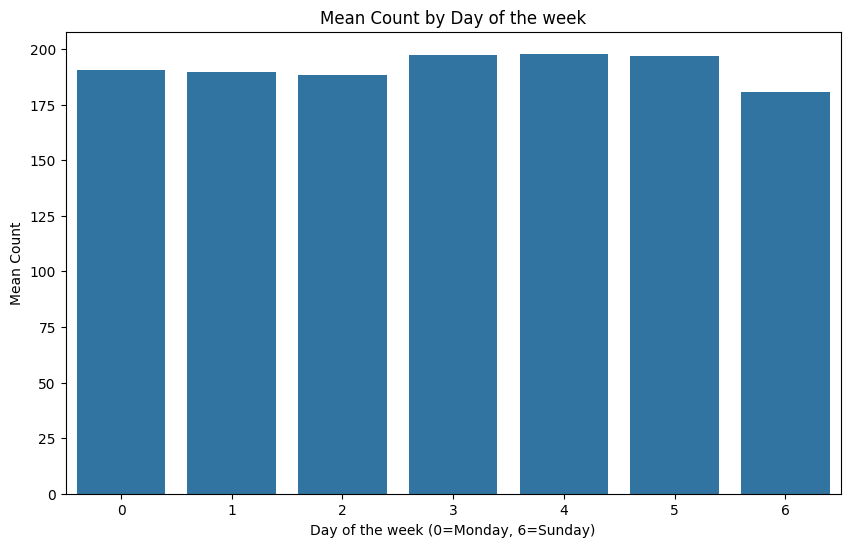

In [38]:
plt.figure(figsize=(10,6))
sns.barplot(data=train_df, x='day_of_week', y='count', errorbar=None)
plt.title('Mean Count by Day of the week')
plt.xlabel('Day of the week (0=Monday, 6=Sunday)')
plt.ylabel('Mean Count')
plt.show()

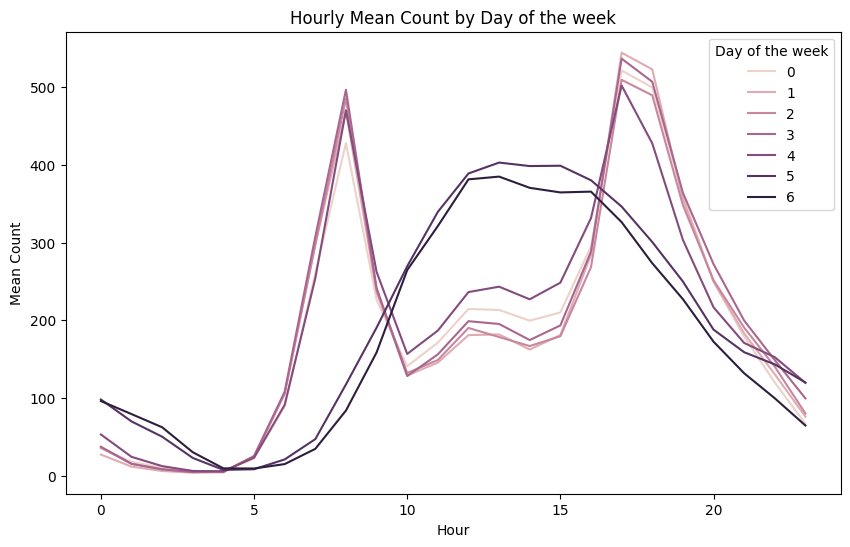

In [41]:
plt.figure(figsize=(10,6))
sns.lineplot(data=train_df, x='hour', y='count', hue='day_of_week', errorbar=None)
plt.title('Hourly Mean Count by Day of the week')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.legend(title='Day of the week')
plt.show()

월요일부터 금요일에 해당하는 0-4의 경우, 아침 6시부터 급격하게 증가해서 대략 9시쯤 가장 높은 대여량을 보이다가 이후로 감소하고 15시부터 서서히 증가해 17-18시쯤 가장 높은 값을 보이지만, 5-6에 해당하는 토요일과 일요일은 10-15시 사이 가장 높은 대여량을 보여준다.

Count 변수 로그 변환하기

- Count 변수처럼 오른쪽으로 치우쳐진 불균형한 데이터가 있을때, 로그 변환을 통해 좀 더 정규분포와 유사한 형태로 만들어줄 수 있다.

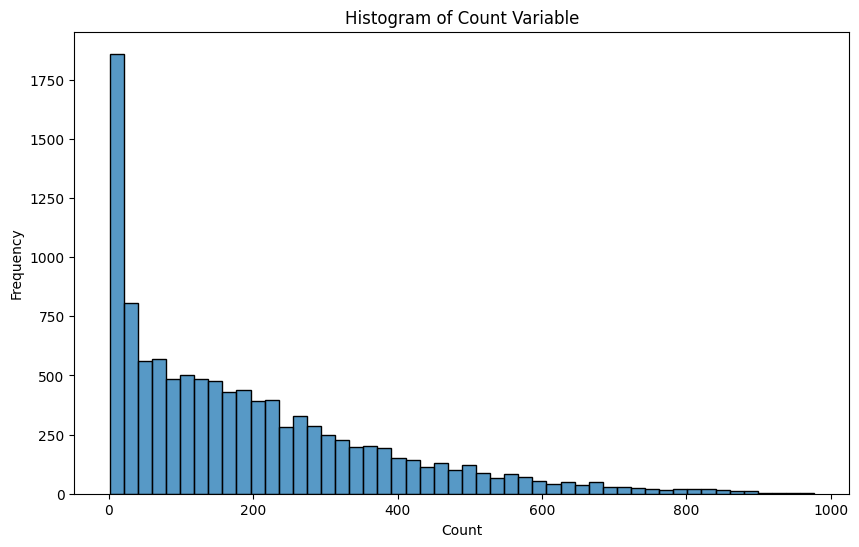

In [44]:
plt.figure(figsize=(10,6))
sns.histplot(train_df['count'], bins=50) #bins는 히스토그램 막대 개수를 가리킨다.
plt.title('Histogram of Count Variable')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()

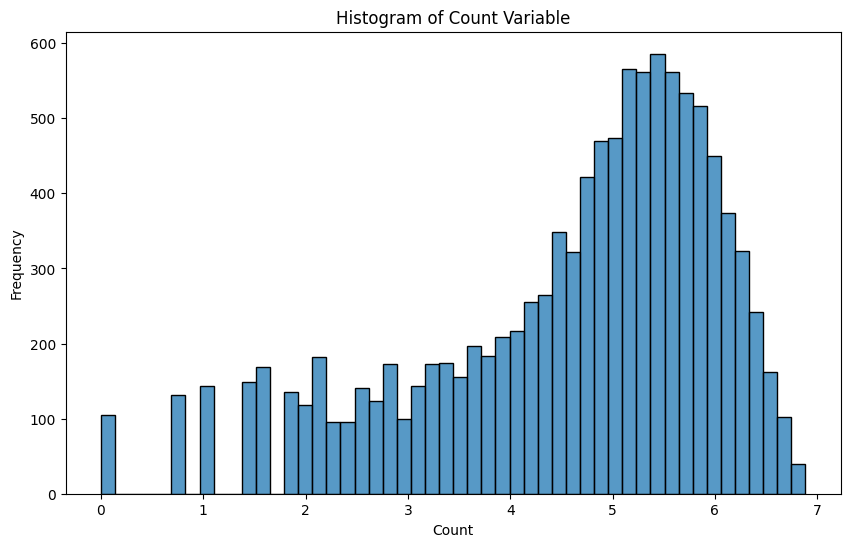

In [43]:
plt.figure(figsize=(10,6))
sns.histplot(np.log(train_df['count']), bins=50)
plt.title('Histogram of Count Variable')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()

#### 모델 학습 및 답안 제출 - 요일 변수 및 로그 변환

In [48]:
def separate_train(df):
    X = df.drop(columns=['count','casual','registered','datetime'], axis=1)
    y = df['count']
    return X, y

def separate_test(df):
    X_test = df.drop('datetime', axis=1)
    return X_test

X, y = separate_train(train_df)
X_test = separate_test(test_df)

print(f'Train data shape : {X.shape}')
print(f'Number of null values : {X.isna().sum().sum()}')
print(f'Test data shape : {X_test.shape}')
print(f'Number of null values : {X_test.isna().sum().sum()}')

X.columns, X_test.columns

Train data shape : (10886, 13)
Number of null values : 0
Test data shape : (6493, 13)
Number of null values : 0


(Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
        'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'day_of_week'],
       dtype='object'),
 Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
        'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'day_of_week'],
       dtype='object'))

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
model = LinearRegression()
model.fit(X_train, np.log(y_train))

y_valid_pred = model.predict(X_valid)
y_valid_pred = np.maximum(1, np.expm1(y_valid_pred)) # 로그 변환된 값을 원래대로 복원

rmsle = np.sqrt(mean_squared_log_error(y_valid, y_valid_pred))
print(f'\nValidation Data RMSLE: {rmsle:.5f}') 

y_test_pred = model.predict(X_test)
y_test_pred = np.maximum(1, np.expm1(y_test_pred))


Validation Data RMSLE: 1.02578


In [53]:
submission_df['count'] = y_test_pred
submission_df.to_csv('result/submission_1.csv', index=False)

성능이 눈에 띄게 좋아졌다.

Private Score / Public Score : 1.05393 / 1.05393

### day3